# Comprehensive Regime Analysis with HMM

This notebook provides comprehensive regime detection and visualization using Hidden Markov Models. We analyze market states, regime transitions, and provide economic interpretation of detected regimes.

## Objectives
- Perform regime detection using the best HMM model from previous analysis
- Visualize regime transitions and state probabilities
- Analyze regime characteristics and persistence
- Provide economic interpretation of detected market states

## Setup and Imports

In [1]:
# Setup notebook environment
import sys
from pathlib import Path

# Add utils to path
sys.path.append('utils')

from utils.notebook_utils import setup_notebook_environment, check_dependencies
from utils.data_loaders import load_sample_data, preprocess_signals, create_multivariate_observations
from utils.plotting_helpers import (
    plot_state_probabilities, plot_transition_matrix, plot_regime_comparison,
    create_interactive_plot, format_regime_stats
)

# Setup environment
project_root = setup_notebook_environment()
check_dependencies()

✓ Notebook environment configured
✓ Project root: /home/nipung2010/fictional-enigma
🔍 Checking dependencies...
✓ All required dependencies available


True

In [2]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import json
import warnings
warnings.filterwarnings('ignore')

# HMM libraries
from hmmlearn import hmm as hmmlearn_hmm
from scipy import stats
from sklearn.metrics import silhouette_score

# Display settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## Load Data and Best Model Configuration

In [3]:
# Load processed data
try:
    # Try to load processed data from data exploration notebook
    df_signals = pd.read_parquet('processed_data/signals_processed.parquet')
    observations = np.load('processed_data/observations.npy')
    print("✅ Loaded processed data from data exploration")
    print(f"   Signals shape: {df_signals.shape}")
    print(f"   Observations shape: {observations.shape}")
except FileNotFoundError:
    print("📊 Creating sample data for regime analysis...")
    df_signals = load_sample_data(n_samples=2000, n_features=3, random_state=42)
    df_processed = preprocess_signals(df_signals, method='standardize')
    observations = create_multivariate_observations(df_processed)
    df_signals = df_processed  # Use processed version
    print(f"   Generated observations shape: {observations.shape}")

print(f"\n📅 Data Range: {df_signals.index.min()} to {df_signals.index.max()}")
print(f"📊 Features: {list(df_signals.columns)}")

✅ Loaded processed data from data exploration
   Signals shape: (2000, 3)
   Observations shape: (2000, 3)

📅 Data Range: 2024-01-01 00:00:00 to 2024-01-07 22:35:00
📊 Features: ['s_signal_1', 's_signal_2', 's_signal_3']


In [4]:
# Load best model configuration from comparison results
try:
    with open('model_comparison_results/best_model_info.json', 'r') as f:
        best_model_info = json.load(f)
    
    recommended_config = best_model_info['model_details']
    print(f"✅ Loaded best model configuration: {best_model_info['recommended_model']}")
    print(f"   Selection criteria: {best_model_info['selection_criteria']}")
    print(f"   Library: {recommended_config['library']}")
    print(f"   States: {recommended_config['n_states']}")
    print(f"   Covariance: {recommended_config['covariance_type']}")
    
except FileNotFoundError:
    print("⚠️  Best model info not found, using default configuration")
    recommended_config = {
        'library': 'hmmlearn',
        'n_states': 3,
        'covariance_type': 'full'
    }
    print(f"   Using default: {recommended_config}")

# Extract configuration parameters
N_STATES = recommended_config['n_states']
COVARIANCE_TYPE = recommended_config['covariance_type']
LIBRARY = recommended_config['library']

✅ Loaded best model configuration: pomegranate_2_full
   Selection criteria: Lowest BIC
   Library: pomegranate
   States: 2
   Covariance: full


## Train HMM Model for Regime Analysis

In [5]:
# Train HMM model with best configuration
print(f"🚀 Training HMM model for regime analysis...")
print(f"   Configuration: {N_STATES} states, {COVARIANCE_TYPE} covariance")

# Create and train model
model = hmmlearn_hmm.GaussianHMM(
    n_components=N_STATES,
    covariance_type=COVARIANCE_TYPE,
    n_iter=200,
    tol=1e-3,
    random_state=42
)

# Train model
start_time = datetime.now()
model.fit(observations)
training_time = (datetime.now() - start_time).total_seconds()

print(f"✅ Model training completed in {training_time:.2f} seconds")
print(f"   Converged: {model.monitor_.converged}")
print(f"   Iterations: {model.monitor_.iter}")
print(f"   Final log-likelihood: {model.score(observations):.2f}")

🚀 Training HMM model for regime analysis...
   Configuration: 2 states, full covariance
✅ Model training completed in 0.07 seconds
   Converged: True
   Iterations: 20
   Final log-likelihood: -7432.49


## Regime Detection and State Probabilities

In [6]:
# Get state probabilities and most likely state sequence
print("🔍 Performing regime detection...")

# State probabilities for each time step
state_probs = model.predict_proba(observations)

# Most likely state sequence (Viterbi algorithm)
state_sequence = model.predict(observations)

print(f"✅ Regime detection completed")
print(f"   State probabilities shape: {state_probs.shape}")
print(f"   State sequence length: {len(state_sequence)}")

# State distribution
unique_states, state_counts = np.unique(state_sequence, return_counts=True)
print(f"\n📊 State Distribution:")
for state, count in zip(unique_states, state_counts):
    percentage = (count / len(state_sequence)) * 100
    print(f"   State {state}: {count} periods ({percentage:.1f}%)")

🔍 Performing regime detection...
✅ Regime detection completed
   State probabilities shape: (2000, 2)
   State sequence length: 2000

📊 State Distribution:
   State 0: 916 periods (45.8%)
   State 1: 1084 periods (54.2%)


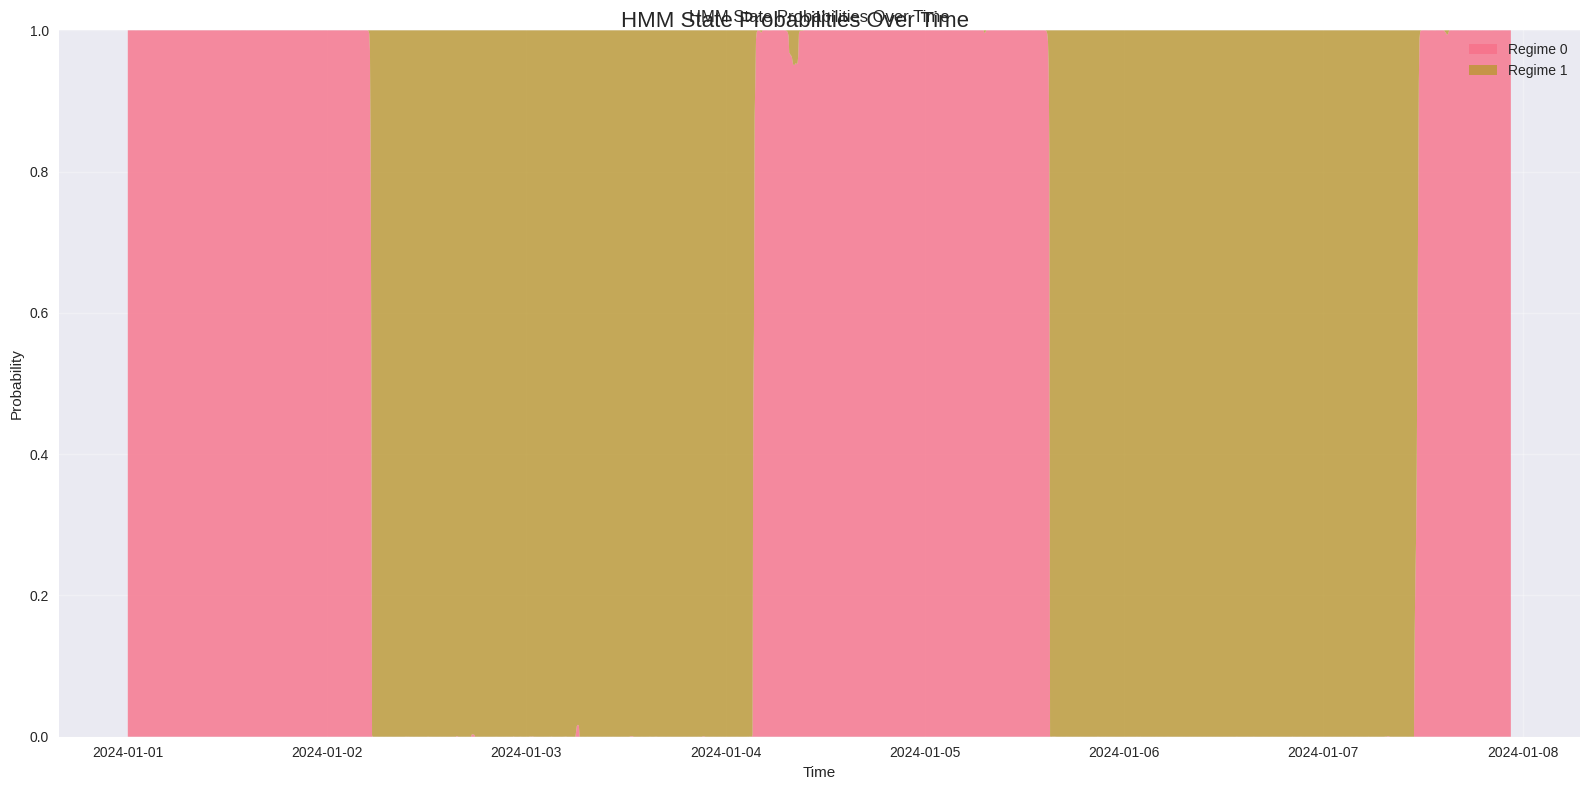

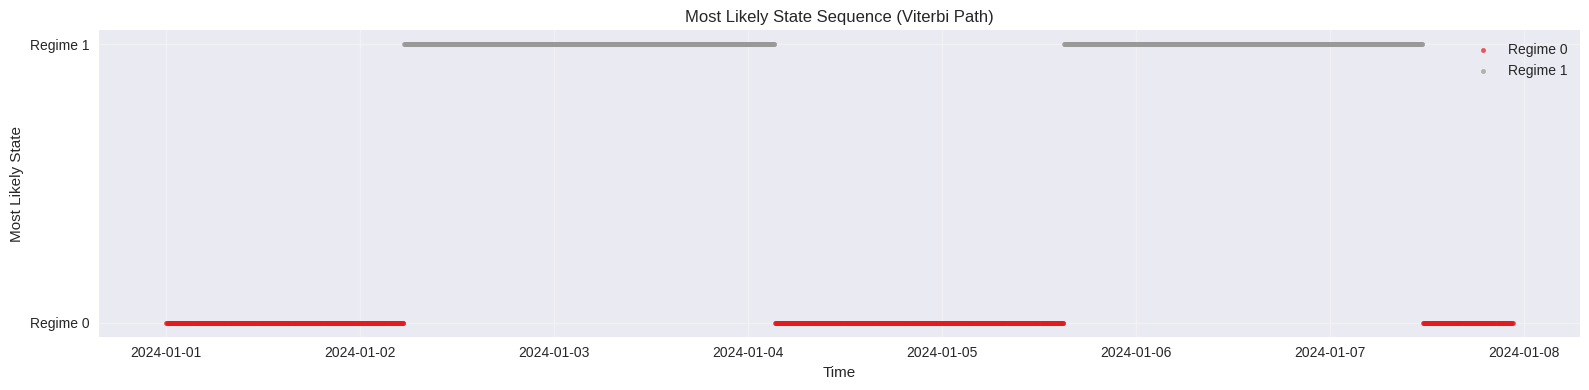

In [7]:
# Visualize state probabilities over time
fig = plot_state_probabilities(
    state_probs,
    timestamps=df_signals.index,
    state_names=[f'Regime {i}' for i in range(N_STATES)],
    figsize=(16, 8)
)
plt.suptitle('HMM State Probabilities Over Time', fontsize=16, y=0.98)
plt.show()

# Plot most likely state sequence
fig, ax = plt.subplots(figsize=(16, 4))
colors = plt.cm.Set1(np.linspace(0, 1, N_STATES))
for state in range(N_STATES):
    mask = state_sequence == state
    ax.scatter(df_signals.index[mask], [state] * mask.sum(), 
              c=[colors[state]], label=f'Regime {state}', alpha=0.7, s=10)

ax.set_ylabel('Most Likely State')
ax.set_xlabel('Time')
ax.set_title('Most Likely State Sequence (Viterbi Path)')
ax.set_yticks(range(N_STATES))
ax.set_yticklabels([f'Regime {i}' for i in range(N_STATES)])
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Regime Characteristics Analysis

In [8]:
# Analyze regime characteristics
print("📈 Analyzing Regime Characteristics")
print("=" * 50)

regime_stats = {}

for state in range(N_STATES):
    # Get observations for this state
    state_mask = state_sequence == state
    state_observations = observations[state_mask]
    state_signals = df_signals.iloc[state_mask]
    
    if len(state_observations) == 0:
        continue
    
    # Calculate statistics
    stats_dict = {
        'n_periods': len(state_observations),
        'percentage': (len(state_observations) / len(observations)) * 100,
        'mean_values': np.mean(state_observations, axis=0),
        'std_values': np.std(state_observations, axis=0),
        'volatility': np.mean(np.std(state_observations, axis=1)),  # Average volatility across features
        'signal_correlations': np.corrcoef(state_observations.T) if len(state_observations) > 1 else np.eye(state_observations.shape[1])
    }
    
    regime_stats[f'regime_{state}'] = stats_dict
    
    print(f"\n🎯 Regime {state} Characteristics:")
    print(f"   Periods: {stats_dict['n_periods']} ({stats_dict['percentage']:.1f}%)")
    print(f"   Average Volatility: {stats_dict['volatility']:.4f}")
    
    # Feature-specific statistics
    for i, col in enumerate(df_signals.columns):
        mean_val = stats_dict['mean_values'][i]
        std_val = stats_dict['std_values'][i]
        print(f"   {col}: μ={mean_val:.4f}, σ={std_val:.4f}")

📈 Analyzing Regime Characteristics

🎯 Regime 0 Characteristics:
   Periods: 916 (45.8%)
   Average Volatility: 0.2975
   s_signal_1: μ=0.2140, σ=0.6991
   s_signal_2: μ=0.2606, σ=0.6860
   s_signal_3: μ=0.3140, σ=0.6611

🎯 Regime 1 Characteristics:
   Periods: 1084 (54.2%)
   Average Volatility: 0.8408
   s_signal_1: μ=-0.1809, σ=1.1661
   s_signal_2: μ=-0.2202, σ=1.1578
   s_signal_3: μ=-0.2654, σ=1.1494


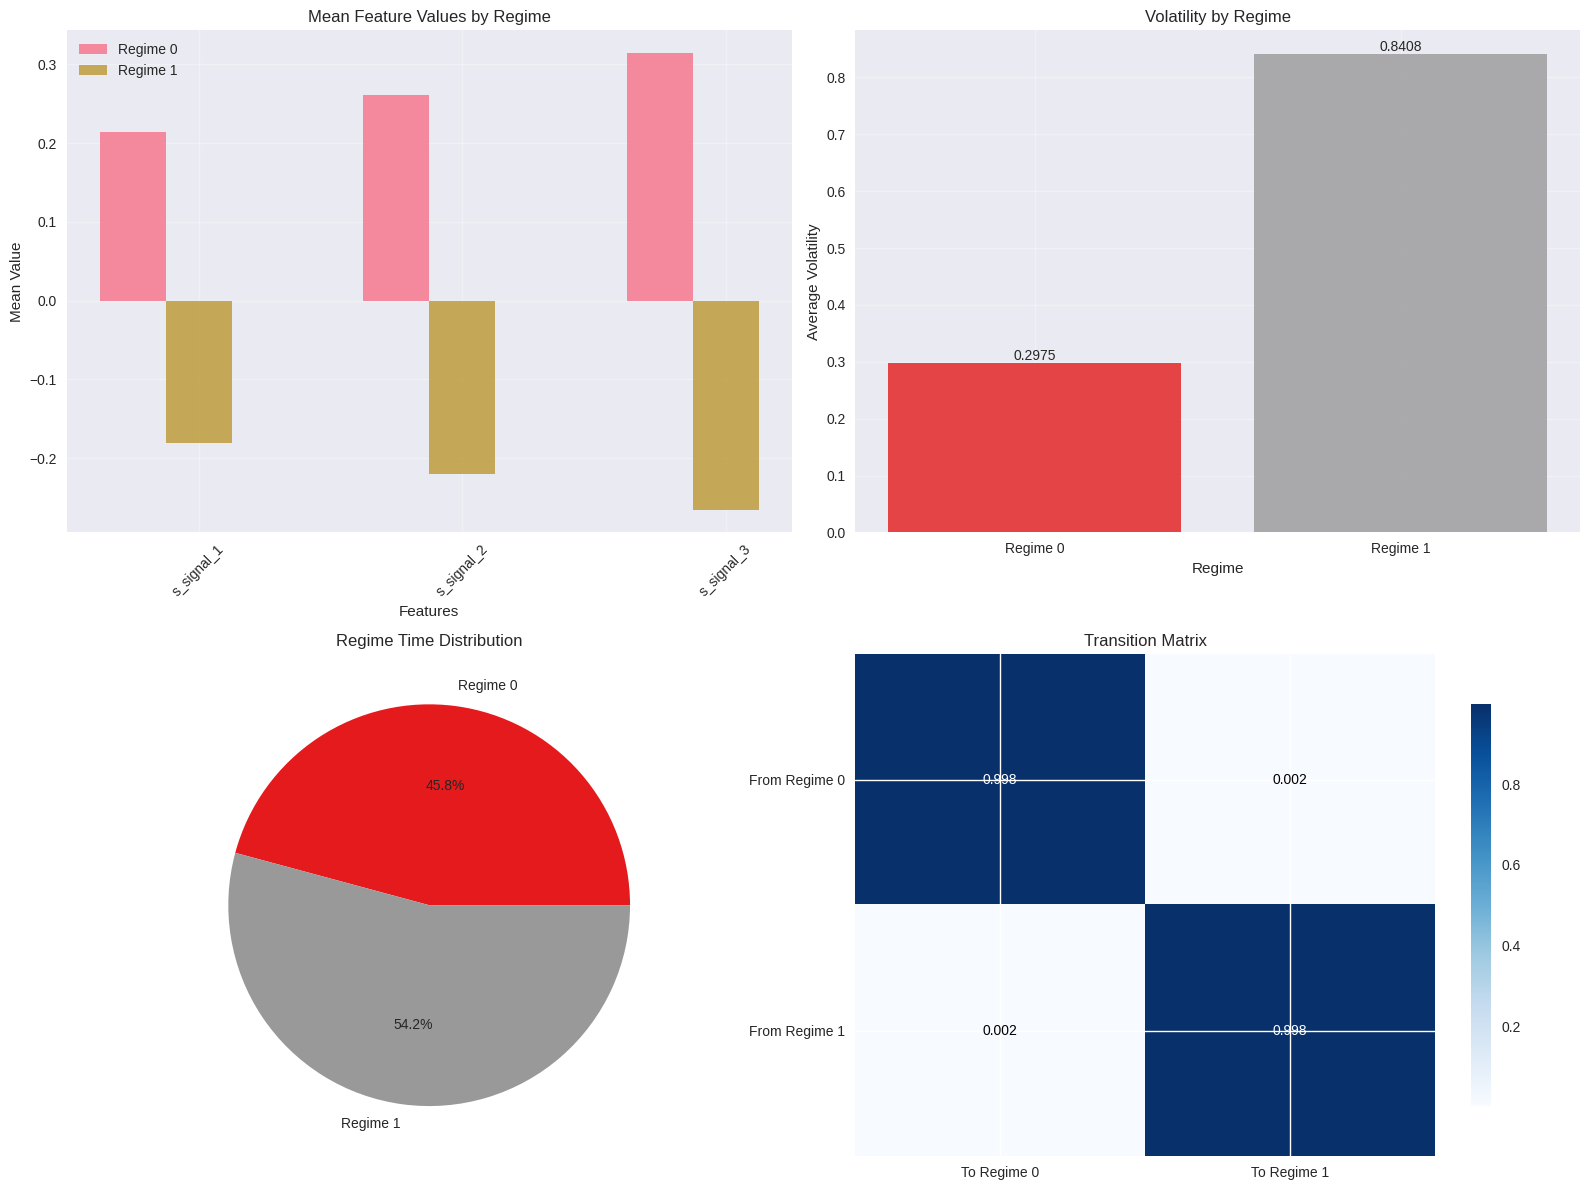

In [9]:
# Visualize regime characteristics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Mean values by regime
ax1 = axes[0, 0]
regime_means = np.array([regime_stats[f'regime_{i}']['mean_values'] for i in range(N_STATES)])
x_pos = np.arange(len(df_signals.columns))
width = 0.25

for i in range(N_STATES):
    ax1.bar(x_pos + i*width, regime_means[i], width, label=f'Regime {i}', alpha=0.8)

ax1.set_xlabel('Features')
ax1.set_ylabel('Mean Value')
ax1.set_title('Mean Feature Values by Regime')
ax1.set_xticks(x_pos + width)
ax1.set_xticklabels(df_signals.columns, rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Volatility by regime
ax2 = axes[0, 1]
volatilities = [regime_stats[f'regime_{i}']['volatility'] for i in range(N_STATES)]
colors = plt.cm.Set1(np.linspace(0, 1, N_STATES))
bars = ax2.bar(range(N_STATES), volatilities, color=colors, alpha=0.8)
ax2.set_xlabel('Regime')
ax2.set_ylabel('Average Volatility')
ax2.set_title('Volatility by Regime')
ax2.set_xticks(range(N_STATES))
ax2.set_xticklabels([f'Regime {i}' for i in range(N_STATES)])
ax2.grid(True, alpha=0.3)

# Add value labels on bars
for bar, vol in zip(bars, volatilities):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{vol:.4f}', ha='center', va='bottom')

# 3. Regime duration distribution
ax3 = axes[1, 0]
periods = [regime_stats[f'regime_{i}']['n_periods'] for i in range(N_STATES)]
ax3.pie(periods, labels=[f'Regime {i}' for i in range(N_STATES)], 
        autopct='%1.1f%%', colors=colors)
ax3.set_title('Regime Time Distribution')

# 4. Transition matrix heatmap
ax4 = axes[1, 1]
transition_matrix = model.transmat_
im = ax4.imshow(transition_matrix, cmap='Blues', aspect='auto')
ax4.set_xticks(range(N_STATES))
ax4.set_yticks(range(N_STATES))
ax4.set_xticklabels([f'To Regime {i}' for i in range(N_STATES)])
ax4.set_yticklabels([f'From Regime {i}' for i in range(N_STATES)])
ax4.set_title('Transition Matrix')

# Add text annotations
for i in range(N_STATES):
    for j in range(N_STATES):
        text = ax4.text(j, i, f'{transition_matrix[i, j]:.3f}',
                       ha="center", va="center", color="black" if transition_matrix[i, j] < 0.5 else "white")

plt.colorbar(im, ax=ax4, shrink=0.8)
plt.tight_layout()
plt.show()

## Regime Persistence and Transition Analysis

In [10]:
# Analyze regime persistence and transitions
def analyze_regime_persistence(state_sequence, min_duration=3):
    """Analyze regime persistence and duration statistics."""
    
    # Find regime runs (consecutive periods in same state)
    regime_runs = []
    current_state = state_sequence[0]
    current_duration = 1
    current_start = 0
    
    for i in range(1, len(state_sequence)):
        if state_sequence[i] == current_state:
            current_duration += 1
        else:
            # End of current run
            regime_runs.append({
                'state': current_state,
                'start': current_start,
                'end': i - 1,
                'duration': current_duration
            })
            
            # Start new run
            current_state = state_sequence[i]
            current_duration = 1
            current_start = i
    
    # Add final run
    regime_runs.append({
        'state': current_state,
        'start': current_start,
        'end': len(state_sequence) - 1,
        'duration': current_duration
    })
    
    # Analyze by state
    persistence_stats = {}
    
    for state in range(N_STATES):
        state_runs = [run for run in regime_runs if run['state'] == state]
        durations = [run['duration'] for run in state_runs]
        
        if durations:
            persistence_stats[f'state_{state}'] = {
                'total_runs': len(durations),
                'mean_duration': np.mean(durations),
                'median_duration': np.median(durations),
                'max_duration': np.max(durations),
                'min_duration': np.min(durations),
                'stable_runs': sum(1 for d in durations if d >= min_duration),
                'stability_ratio': sum(1 for d in durations if d >= min_duration) / len(durations)
            }
    
    return regime_runs, persistence_stats

# Perform persistence analysis
regime_runs, persistence_stats = analyze_regime_persistence(state_sequence, min_duration=5)

print("⏱️  Regime Persistence Analysis")
print("=" * 50)
print(f"Total regime runs: {len(regime_runs)}")

for state in range(N_STATES):
    if f'state_{state}' in persistence_stats:
        stats = persistence_stats[f'state_{state}']
        print(f"\n📊 Regime {state} Persistence:")
        print(f"   Total runs: {stats['total_runs']}")
        print(f"   Mean duration: {stats['mean_duration']:.2f} periods")
        print(f"   Median duration: {stats['median_duration']:.2f} periods")
        print(f"   Max duration: {stats['max_duration']} periods")
        print(f"   Stable runs (≥5 periods): {stats['stable_runs']} ({stats['stability_ratio']:.1%})")

⏱️  Regime Persistence Analysis
Total regime runs: 5

📊 Regime 0 Persistence:
   Total runs: 3
   Mean duration: 305.33 periods
   Median duration: 353.00 periods
   Max duration: 429 periods
   Stable runs (≥5 periods): 3 (100.0%)

📊 Regime 1 Persistence:
   Total runs: 2
   Mean duration: 542.00 periods
   Median duration: 542.00 periods
   Max duration: 551 periods
   Stable runs (≥5 periods): 2 (100.0%)


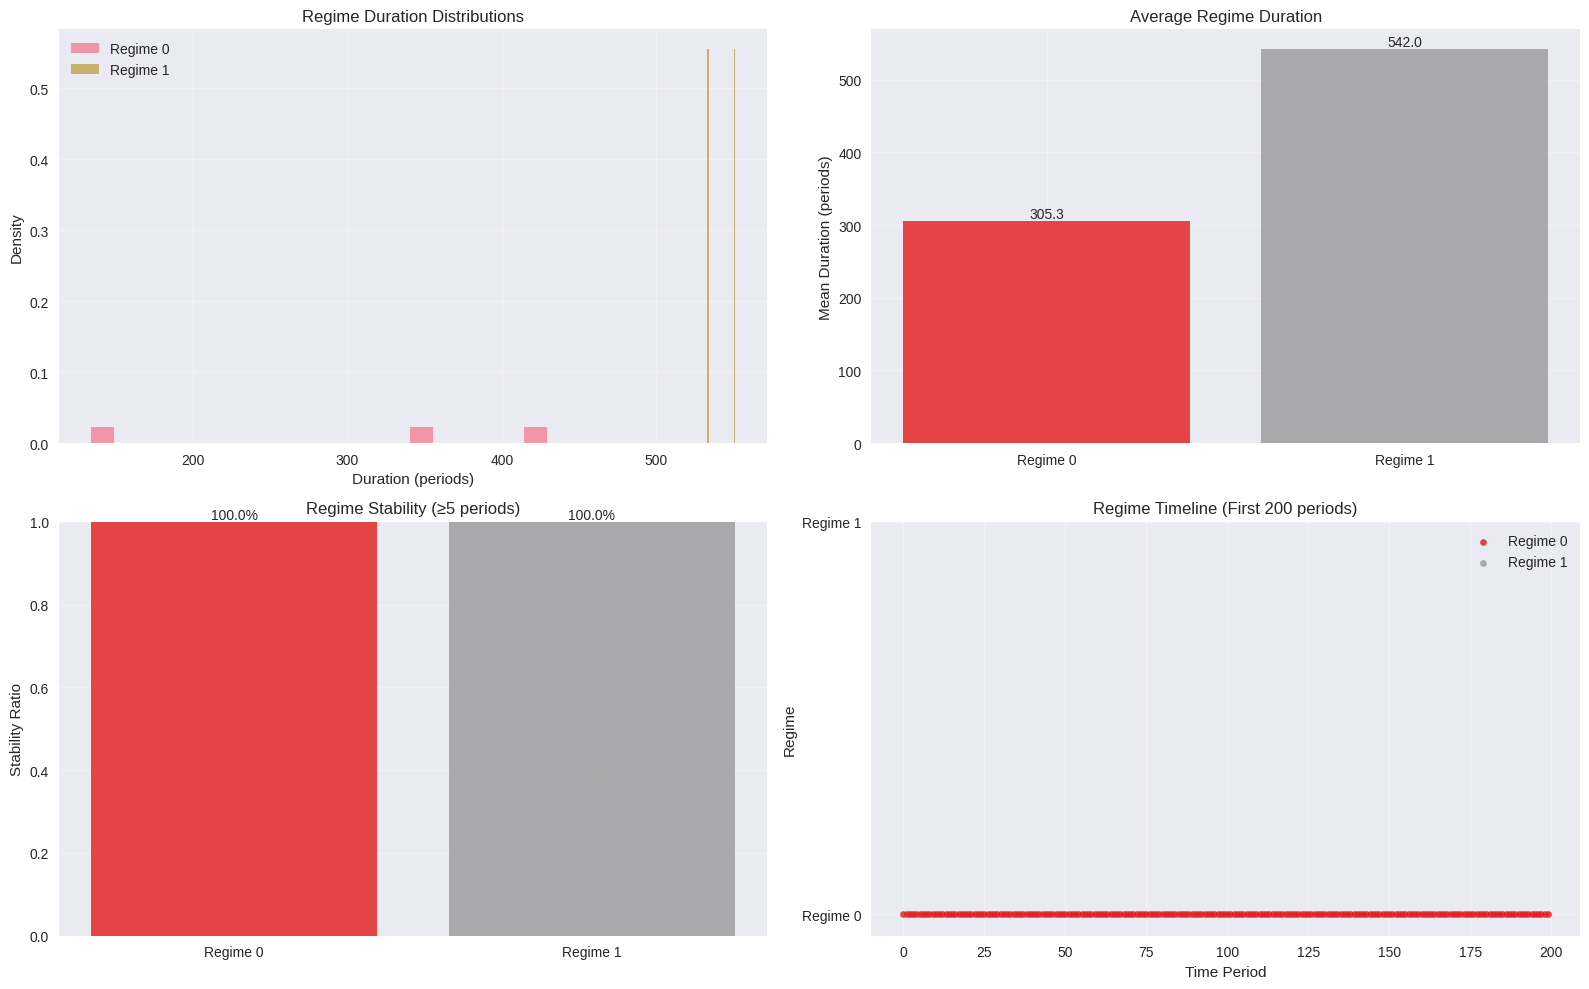

In [11]:
# Visualize regime persistence
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Duration distributions
ax1 = axes[0, 0]
for state in range(N_STATES):
    state_runs = [run for run in regime_runs if run['state'] == state]
    durations = [run['duration'] for run in state_runs]
    if durations:
        ax1.hist(durations, bins=20, alpha=0.7, label=f'Regime {state}', density=True)

ax1.set_xlabel('Duration (periods)')
ax1.set_ylabel('Density')
ax1.set_title('Regime Duration Distributions')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Mean durations by regime
ax2 = axes[0, 1]
mean_durations = [persistence_stats[f'state_{i}']['mean_duration'] 
                 for i in range(N_STATES) if f'state_{i}' in persistence_stats]
regime_labels = [f'Regime {i}' for i in range(N_STATES) if f'state_{i}' in persistence_stats]

bars = ax2.bar(regime_labels, mean_durations, color=colors[:len(mean_durations)], alpha=0.8)
ax2.set_ylabel('Mean Duration (periods)')
ax2.set_title('Average Regime Duration')
ax2.grid(True, alpha=0.3)

# Add value labels
for bar, duration in zip(bars, mean_durations):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{duration:.1f}', ha='center', va='bottom')

# 3. Stability ratios
ax3 = axes[1, 0]
stability_ratios = [persistence_stats[f'state_{i}']['stability_ratio'] 
                   for i in range(N_STATES) if f'state_{i}' in persistence_stats]

bars = ax3.bar(regime_labels, stability_ratios, color=colors[:len(stability_ratios)], alpha=0.8)
ax3.set_ylabel('Stability Ratio')
ax3.set_title('Regime Stability (≥5 periods)')
ax3.set_ylim(0, 1)
ax3.grid(True, alpha=0.3)

# Add percentage labels
for bar, ratio in zip(bars, stability_ratios):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{ratio:.1%}', ha='center', va='bottom')

# 4. Regime timeline (sample)
ax4 = axes[1, 1]
sample_length = min(200, len(state_sequence))  # Show first 200 periods
sample_sequence = state_sequence[:sample_length]
sample_times = range(sample_length)

for state in range(N_STATES):
    mask = sample_sequence == state
    ax4.scatter(np.array(sample_times)[mask], sample_sequence[mask], 
               c=[colors[state]], label=f'Regime {state}', alpha=0.8, s=20)

ax4.set_xlabel('Time Period')
ax4.set_ylabel('Regime')
ax4.set_title(f'Regime Timeline (First {sample_length} periods)')
ax4.set_yticks(range(N_STATES))
ax4.set_yticklabels([f'Regime {i}' for i in range(N_STATES)])
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Signal Analysis by Regime

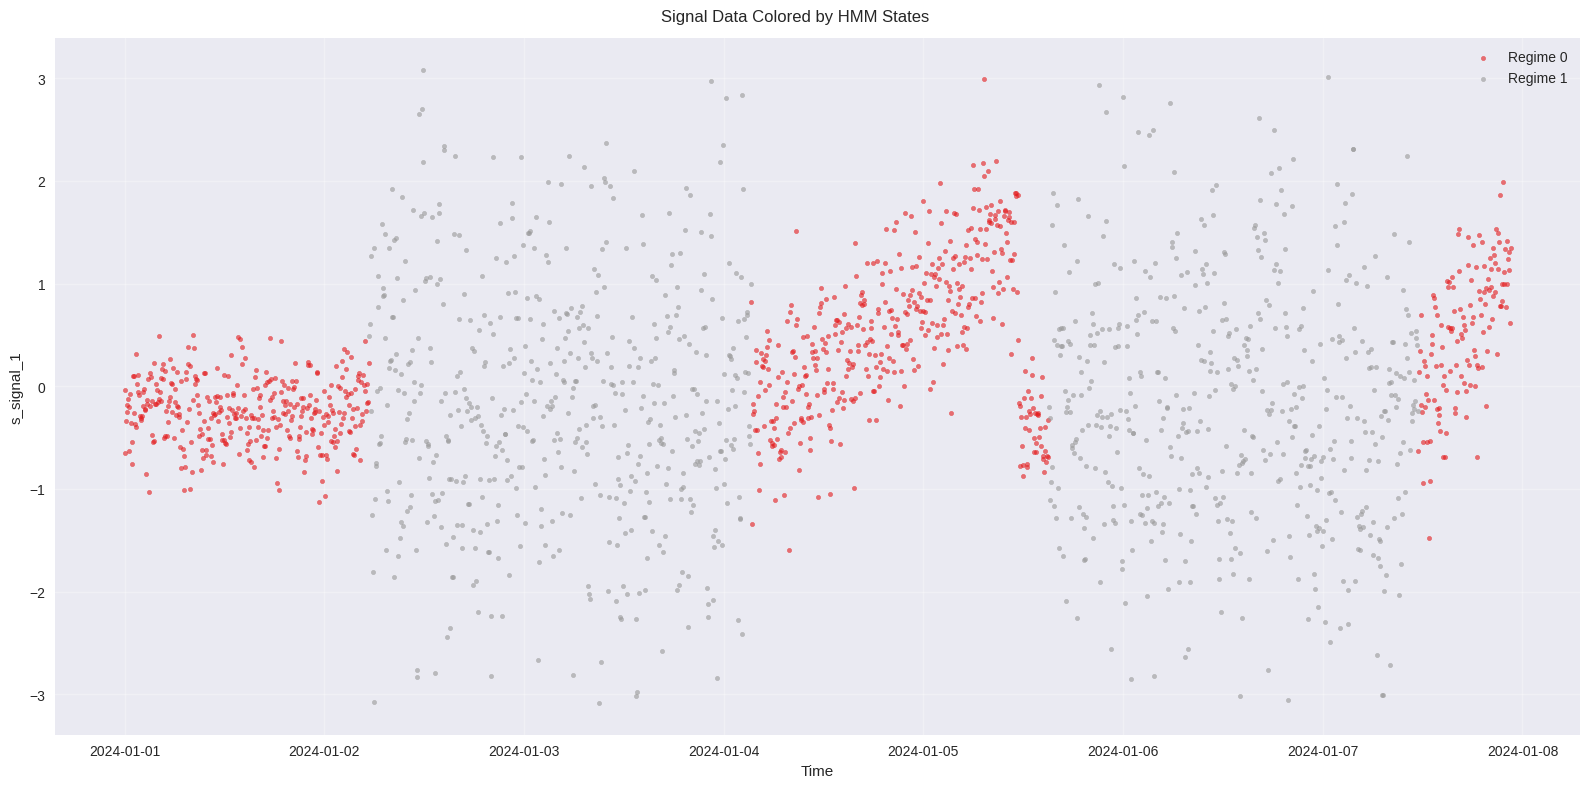

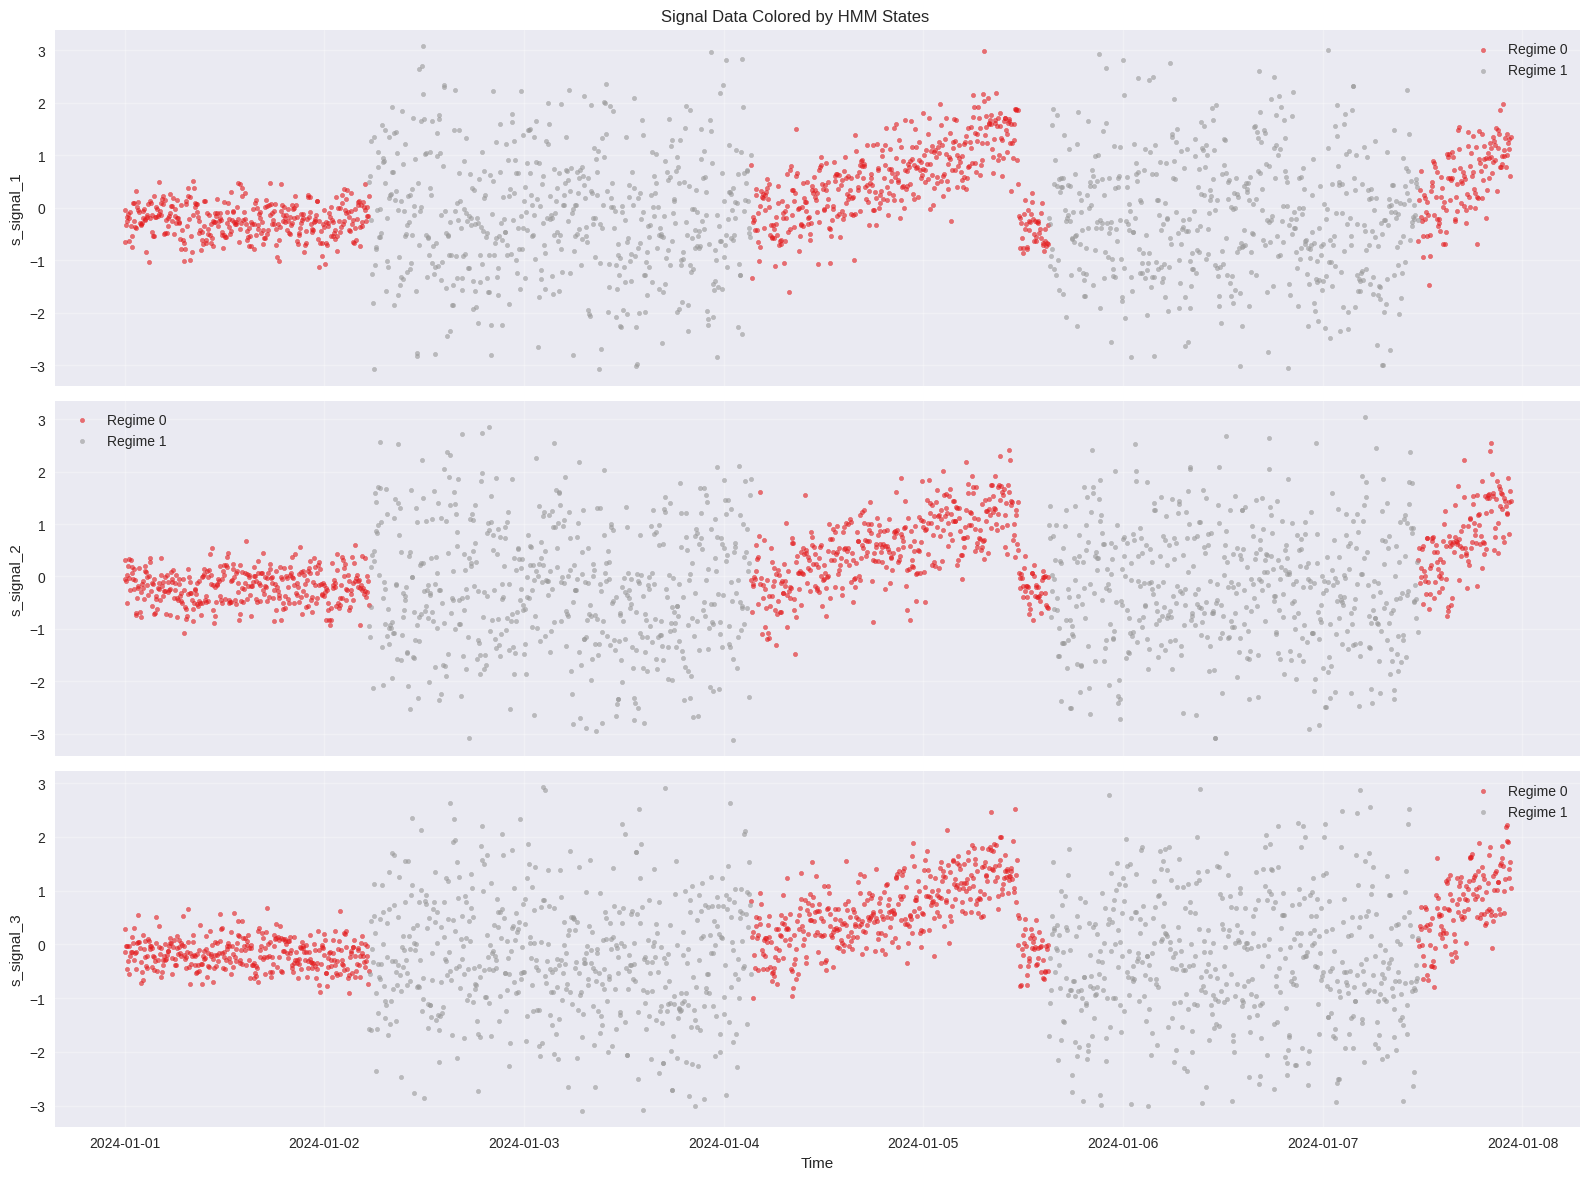

In [12]:
# Analyze signals colored by regime
if len(df_signals.columns) > 0:
    # Plot first signal colored by regime
    first_signal = df_signals.columns[0]
    fig = plot_regime_comparison(
        df_signals,
        state_sequence,
        state_names=[f'Regime {i}' for i in range(N_STATES)],
        signal_col=first_signal,
        figsize=(16, 8)
    )
    plt.show()
    
    # Plot all signals if there are multiple
    if len(df_signals.columns) > 1:
        fig = plot_regime_comparison(
            df_signals,
            state_sequence,
            state_names=[f'Regime {i}' for i in range(N_STATES)],
            figsize=(16, 12)
        )
        plt.show()

## Economic Interpretation of Regimes

In [13]:
# Provide economic interpretation of detected regimes
def interpret_regimes(regime_stats, persistence_stats, transition_matrix):
    """Provide economic interpretation of detected regimes."""
    
    interpretations = {}
    
    for state in range(N_STATES):
        if f'regime_{state}' not in regime_stats:
            continue
            
        stats = regime_stats[f'regime_{state}']
        persistence = persistence_stats.get(f'state_{state}', {})
        
        # Analyze characteristics
        volatility = stats['volatility']
        mean_values = stats['mean_values']
        duration = persistence.get('mean_duration', 0)
        stability = persistence.get('stability_ratio', 0)
        
        # Classify regime type based on characteristics
        regime_type = "Unknown"
        description = ""
        
        if volatility < np.mean([regime_stats[f'regime_{i}']['volatility'] 
                                for i in range(N_STATES) if f'regime_{i}' in regime_stats]) * 0.8:
            regime_type = "Low Volatility"
            description = "Calm market conditions with low volatility and stable price movements."
        elif volatility > np.mean([regime_stats[f'regime_{i}']['volatility'] 
                                 for i in range(N_STATES) if f'regime_{i}' in regime_stats]) * 1.2:
            regime_type = "High Volatility"
            description = "Turbulent market conditions with high volatility and large price swings."
        else:
            regime_type = "Moderate Volatility"
            description = "Normal market conditions with moderate volatility."
        
        # Add persistence information
        if stability > 0.6:
            persistence_desc = "highly persistent"
        elif stability > 0.3:
            persistence_desc = "moderately persistent"
        else:
            persistence_desc = "transient"
        
        interpretations[f'regime_{state}'] = {
            'type': regime_type,
            'description': description,
            'persistence': persistence_desc,
            'avg_duration': duration,
            'stability_ratio': stability,
            'volatility_level': 'Low' if volatility < 0.5 else 'High' if volatility > 1.5 else 'Moderate'
        }
    
    return interpretations

# Generate interpretations
regime_interpretations = interpret_regimes(regime_stats, persistence_stats, model.transmat_)

print("🎯 Economic Interpretation of Detected Regimes")
print("=" * 60)

for state in range(N_STATES):
    if f'regime_{state}' in regime_interpretations:
        interp = regime_interpretations[f'regime_{state}']
        
        print(f"\n📊 Regime {state}: {interp['type']}")
        print(f"   Description: {interp['description']}")
        print(f"   Persistence: {interp['persistence']} (avg duration: {interp['avg_duration']:.1f} periods)")
        print(f"   Stability: {interp['stability_ratio']:.1%} of runs are stable (≥5 periods)")
        print(f"   Volatility: {interp['volatility_level']}")
        
        # Transition tendencies
        transition_probs = model.transmat_[state]
        most_likely_next = np.argmax(transition_probs)
        if most_likely_next == state:
            print(f"   Tendency: Likely to persist (self-transition: {transition_probs[state]:.1%})")
        else:
            print(f"   Tendency: Likely to transition to Regime {most_likely_next} ({transition_probs[most_likely_next]:.1%})")

🎯 Economic Interpretation of Detected Regimes

📊 Regime 0: Low Volatility
   Description: Calm market conditions with low volatility and stable price movements.
   Persistence: highly persistent (avg duration: 305.3 periods)
   Stability: 100.0% of runs are stable (≥5 periods)
   Volatility: Low
   Tendency: Likely to persist (self-transition: 99.8%)

📊 Regime 1: High Volatility
   Description: Turbulent market conditions with high volatility and large price swings.
   Persistence: highly persistent (avg duration: 542.0 periods)
   Stability: 100.0% of runs are stable (≥5 periods)
   Volatility: Moderate
   Tendency: Likely to persist (self-transition: 99.8%)


## Regime Quality Assessment

In [14]:
# Assess regime detection quality
print("🔍 Regime Detection Quality Assessment")
print("=" * 50)

# 1. Silhouette score for regime separation
try:
    silhouette_avg = silhouette_score(observations, state_sequence)
    print(f"📊 Silhouette Score: {silhouette_avg:.4f}")
    
    if silhouette_avg > 0.5:
        print("   ✅ Excellent regime separation")
    elif silhouette_avg > 0.3:
        print("   ✅ Good regime separation")
    elif silhouette_avg > 0.1:
        print("   ⚠️  Moderate regime separation")
    else:
        print("   ❌ Poor regime separation")
except Exception as e:
    print(f"   ⚠️  Could not calculate silhouette score: {e}")

# 2. Regime stability metrics
total_transitions = len(regime_runs) - 1
avg_duration = np.mean([run['duration'] for run in regime_runs])
stable_runs = sum(1 for run in regime_runs if run['duration'] >= 5)
stability_ratio = stable_runs / len(regime_runs)

print(f"\n⏱️  Stability Metrics:")
print(f"   Total regime transitions: {total_transitions}")
print(f"   Average regime duration: {avg_duration:.2f} periods")
print(f"   Stable regimes (≥5 periods): {stable_runs}/{len(regime_runs)} ({stability_ratio:.1%})")

# 3. Model fit quality
log_likelihood = model.score(observations)
n_params = N_STATES * (N_STATES - 1) + (N_STATES - 1) + N_STATES * observations.shape[1] * 2  # Simplified parameter count
aic = 2 * n_params - 2 * log_likelihood
bic = np.log(len(observations)) * n_params - 2 * log_likelihood

print(f"\n📈 Model Fit Quality:")
print(f"   Log-likelihood: {log_likelihood:.2f}")
print(f"   AIC: {aic:.2f}")
print(f"   BIC: {bic:.2f}")
print(f"   Converged: {model.monitor_.converged}")

# 4. Regime balance
regime_balance = np.std([regime_stats[f'regime_{i}']['percentage'] 
                        for i in range(N_STATES) if f'regime_{i}' in regime_stats])
print(f"\n⚖️  Regime Balance:")
print(f"   Standard deviation of regime percentages: {regime_balance:.2f}%")
if regime_balance < 10:
    print("   ✅ Well-balanced regimes")
elif regime_balance < 20:
    print("   ⚠️  Moderately balanced regimes")
else:
    print("   ❌ Imbalanced regimes - one regime dominates")

🔍 Regime Detection Quality Assessment
📊 Silhouette Score: 0.0830
   ❌ Poor regime separation

⏱️  Stability Metrics:
   Total regime transitions: 4
   Average regime duration: 400.00 periods
   Stable regimes (≥5 periods): 5/5 (100.0%)

📈 Model Fit Quality:
   Log-likelihood: -7432.49
   AIC: 14894.98
   BIC: 14978.99
   Converged: True

⚖️  Regime Balance:
   Standard deviation of regime percentages: 4.20%
   ✅ Well-balanced regimes


## Export Regime Analysis Results

In [15]:
# Export comprehensive regime analysis results
output_dir = Path('regime_analysis_results')
output_dir.mkdir(exist_ok=True)

# 1. Save state probabilities and sequence
np.save(output_dir / 'state_probabilities.npy', state_probs)
np.save(output_dir / 'state_sequence.npy', state_sequence)

# 2. Save regime statistics
regime_analysis_results = {
    'model_config': {
        'n_states': N_STATES,
        'covariance_type': COVARIANCE_TYPE,
        'library': LIBRARY
    },
    'model_performance': {
        'log_likelihood': float(log_likelihood),
        'aic': float(aic),
        'bic': float(bic),
        'converged': bool(model.monitor_.converged),
        'iterations': int(model.monitor_.iter),
        'training_time': training_time
    },
    'regime_statistics': {k: {**v, 'mean_values': v['mean_values'].tolist(), 
                             'std_values': v['std_values'].tolist(),
                             'signal_correlations': v['signal_correlations'].tolist()} 
                         for k, v in regime_stats.items()},
    'persistence_statistics': persistence_stats,
    'regime_interpretations': regime_interpretations,
    'transition_matrix': model.transmat_.tolist(),
    'start_probabilities': model.startprob_.tolist(),
    'quality_metrics': {
        'silhouette_score': float(silhouette_avg) if 'silhouette_avg' in locals() else None,
        'average_duration': float(avg_duration),
        'stability_ratio': float(stability_ratio),
        'regime_balance': float(regime_balance)
    },
    'created_at': str(datetime.now())
}

# Save as JSON
with open(output_dir / 'regime_analysis_results.json', 'w') as f:
    json.dump(regime_analysis_results, f, indent=2, default=str)

# 3. Save regime-labeled data
df_with_regimes = df_signals.copy()
df_with_regimes['regime'] = state_sequence
df_with_regimes['regime_prob_0'] = state_probs[:, 0]
if N_STATES > 1:
    df_with_regimes['regime_prob_1'] = state_probs[:, 1]
if N_STATES > 2:
    df_with_regimes['regime_prob_2'] = state_probs[:, 2]

df_with_regimes.to_parquet(output_dir / 'signals_with_regimes.parquet')
df_with_regimes.to_csv(output_dir / 'signals_with_regimes.csv')

print(f"✅ Regime analysis results exported to {output_dir}/")
print(f"   - regime_analysis_results.json (comprehensive results)")
print(f"   - state_probabilities.npy (state probabilities array)")
print(f"   - state_sequence.npy (most likely state sequence)")
print(f"   - signals_with_regimes.parquet (signals with regime labels)")
print(f"   - signals_with_regimes.csv (signals with regime labels)")

✅ Regime analysis results exported to regime_analysis_results/
   - regime_analysis_results.json (comprehensive results)
   - state_probabilities.npy (state probabilities array)
   - state_sequence.npy (most likely state sequence)
   - signals_with_regimes.parquet (signals with regime labels)
   - signals_with_regimes.csv (signals with regime labels)


## Summary and Recommendations

In [16]:
print("📋 Regime Analysis Summary")
print("=" * 60)
print(f"✅ Model Configuration: {N_STATES} states, {COVARIANCE_TYPE} covariance")
print(f"✅ Training: Converged in {model.monitor_.iter} iterations ({training_time:.2f}s)")
print(f"✅ Model Fit: Log-likelihood = {log_likelihood:.2f}, BIC = {bic:.2f}")
print(f"✅ Regime Detection: {len(regime_runs)} regime periods identified")
print(f"✅ Average Regime Duration: {avg_duration:.2f} periods")
print(f"✅ Regime Stability: {stability_ratio:.1%} of regimes are stable (≥5 periods)")

if 'silhouette_avg' in locals():
    print(f"✅ Regime Separation: Silhouette score = {silhouette_avg:.4f}")

print(f"\n🎯 Detected Regime Types:")
for state in range(N_STATES):
    if f'regime_{state}' in regime_interpretations:
        interp = regime_interpretations[f'regime_{state}']
        percentage = regime_stats[f'regime_{state}']['percentage']
        print(f"   Regime {state}: {interp['type']} ({percentage:.1f}% of time, {interp['persistence']})")

print(f"\n💡 Key Insights:")
# Find most persistent regime
most_persistent_state = max(range(N_STATES), 
                           key=lambda s: persistence_stats.get(f'state_{s}', {}).get('mean_duration', 0))
most_persistent_duration = persistence_stats.get(f'state_{most_persistent_state}', {}).get('mean_duration', 0)

# Find most volatile regime
most_volatile_state = max(range(N_STATES),
                         key=lambda s: regime_stats.get(f'regime_{s}', {}).get('volatility', 0))
most_volatile_vol = regime_stats.get(f'regime_{most_volatile_state}', {}).get('volatility', 0)

print(f"   - Most persistent regime: Regime {most_persistent_state} (avg {most_persistent_duration:.1f} periods)")
print(f"   - Most volatile regime: Regime {most_volatile_state} (volatility {most_volatile_vol:.4f})")
print(f"   - Regime transitions occur approximately every {avg_duration:.1f} periods")

# Transition insights
diagonal_sum = np.trace(model.transmat_)
persistence_tendency = diagonal_sum / N_STATES
print(f"   - Overall persistence tendency: {persistence_tendency:.1%} (higher = more persistent regimes)")

print(f"\n🚀 Next Steps:")
print(f"   1. Use 04_parameter_optimization.ipynb for hyperparameter tuning")
print(f"   2. Consider regime-specific trading strategies based on detected characteristics")
print(f"   3. Validate regime detection against known market events")
print(f"   4. Implement regime-aware fusion weights for the LDC system")

print(f"\n📁 Output Files:")
print(f"   - regime_analysis_results/ (comprehensive analysis results)")
print(f"   - signals_with_regimes.parquet (data with regime labels for further analysis)")

📋 Regime Analysis Summary
✅ Model Configuration: 2 states, full covariance
✅ Training: Converged in 20 iterations (0.07s)
✅ Model Fit: Log-likelihood = -7432.49, BIC = 14978.99
✅ Regime Detection: 5 regime periods identified
✅ Average Regime Duration: 400.00 periods
✅ Regime Stability: 100.0% of regimes are stable (≥5 periods)
✅ Regime Separation: Silhouette score = 0.0830

🎯 Detected Regime Types:
   Regime 0: Low Volatility (45.8% of time, highly persistent)
   Regime 1: High Volatility (54.2% of time, highly persistent)

💡 Key Insights:
   - Most persistent regime: Regime 1 (avg 542.0 periods)
   - Most volatile regime: Regime 1 (volatility 0.8408)
   - Regime transitions occur approximately every 400.0 periods
   - Overall persistence tendency: 99.8% (higher = more persistent regimes)

🚀 Next Steps:
   1. Use 04_parameter_optimization.ipynb for hyperparameter tuning
   2. Consider regime-specific trading strategies based on detected characteristics
   3. Validate regime detection a